# Task: 
## 1. Crawl the restaurants and their information on the provided website
## 2. Identify the most unique restaurant among the crawled restaurant (Using Cosine Similarity) 
## 3. Provide suggestions for someone planning to open a new restaurant in this community.
# Skills: Webscraping, Data Preprocessing, Data Analysis, Data Visualization, Data Interpretation

In [216]:
from bs4 import BeautifulSoup
import urllib.request as req

In [218]:
url = "https://www.opentable.com/landmark/restaurants-near-rodeo-drive"
html = req.urlopen(url)
doc = BeautifulSoup(html, "html.parser")

### Visit the webpages of the 10 restaurants listed on the first page and crawl their names and descriptions

In [222]:
names = doc.find_all(class_="FhfgYo4tTD0-")
names

[<h6 class="FhfgYo4tTD0-">1. <!-- -->Ocean Prime - Beverly Hills</h6>,
 <h6 class="FhfgYo4tTD0-">2. <!-- -->Jade Beverly Hills</h6>,
 <h6 class="FhfgYo4tTD0-">3. <!-- -->The Hideaway</h6>,
 <h6 class="FhfgYo4tTD0-">4. <!-- -->Negroni Beverly Hills</h6>,
 <h6 class="FhfgYo4tTD0-">5. <!-- -->CUT by Wolfgang Puck at Beverly Wilshire</h6>,
 <h6 class="FhfgYo4tTD0-">6. <!-- -->208 Rodeo - Beverly Hills</h6>,
 <h6 class="FhfgYo4tTD0-">7. <!-- -->THE Blvd - Beverly Wilshire Hotel</h6>,
 <h6 class="FhfgYo4tTD0-">8. <!-- -->Nua</h6>,
 <h6 class="FhfgYo4tTD0-">9. <!-- -->The Grill on the Alley - Beverly Hills</h6>,
 <h6 class="FhfgYo4tTD0-">10. <!-- -->Cipriani Beverly Hills</h6>]

In [224]:
names0 = [n.text for n in names]
names0

['1. Ocean Prime - Beverly Hills',
 '2. Jade Beverly Hills',
 '3. The Hideaway',
 '4. Negroni Beverly Hills',
 '5. CUT by Wolfgang Puck at Beverly Wilshire',
 '6. 208 Rodeo - Beverly Hills',
 '7. THE Blvd - Beverly Wilshire Hotel',
 '8. Nua',
 '9. The Grill on the Alley - Beverly Hills',
 '10. Cipriani Beverly Hills']

In [226]:
des = doc.find_all(class_="l9bbXUdC9v0- _3YSslEmZu4g- C7Tp-bANpE4- l-AMWW5ZrIg-")

In [228]:
des0 = [d.text for d in des]
des0

['Located just steps from Rodeo Drive, Ocean Prime is a nationally acclaimed, dynamic seafood & steakhouse from the award-winning Cameron Mitchell Restaurants. Ocean Prime delivers an elevated experience with exceptional ambiance, a chef-curated menu, signature handcrafted cocktails, Wine Spectator honored wine list and genuine hospitality. Reservations are recommended. Ocean Prime strives to provide an elegant, fine dining atmosphere. Our associates’ priority is to ensure your experience is memorable. We ask that our guests choose attire that is both polished and suited to our restaurant.THANK YOU FOR NOT WEARING: Clothing emitting excessive marijuana odor Excessively revealing clothing or exposed undergarments Clothing with offensive language or graphics Admittance to Ocean Prime is at the discretion of management who reserves the right to refuse service to patrons who are inappropriately dressed. ',
 'At Jade, we redefine Japanese cuisine in Beverly Hills, blending tradition with en

###  Data Preprocessing: Use TF-IDF scores, convert upper case letters to lower case, delete stopwords, and stem the words.

In [232]:
from nltk.tokenize import word_tokenize

In [234]:
from nltk.corpus import stopwords

In [236]:
nltk_stopwords = set(stopwords.words("english"))
nltk_stopwords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [238]:
my_stopwords = ["please", "join", "us"]

In [240]:
new_stopwords = nltk_stopwords.union(my_stopwords)
new_stopwords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'join',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'on

In [242]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [244]:
for d in des0:
    d1 = word_tokenize(d)
    d2 = [w.lower() for w in d1 if w .isalpha()]
    d3 = [w for w in d2 if not w in new_stopwords]
    d4 = [ps.stem(w) for w in d3]
    print(d4)

['locat', 'step', 'rodeo', 'drive', 'ocean', 'prime', 'nation', 'acclaim', 'dynam', 'seafood', 'steakhous', 'cameron', 'mitchel', 'restaur', 'ocean', 'prime', 'deliv', 'elev', 'experi', 'except', 'ambianc', 'menu', 'signatur', 'handcraft', 'cocktail', 'wine', 'spectat', 'honor', 'wine', 'list', 'genuin', 'hospit', 'reserv', 'recommend', 'ocean', 'prime', 'strive', 'provid', 'eleg', 'fine', 'dine', 'atmospher', 'associ', 'prioriti', 'ensur', 'experi', 'memor', 'ask', 'guest', 'choos', 'attir', 'polish', 'suit', 'wear', 'cloth', 'emit', 'excess', 'marijuana', 'odor', 'excess', 'reveal', 'cloth', 'expos', 'undergar', 'cloth', 'offens', 'languag', 'graphic', 'admitt', 'ocean', 'prime', 'discret', 'manag', 'reserv', 'right', 'refus', 'servic', 'patron', 'inappropri', 'dress']
['jade', 'redefin', 'japanes', 'cuisin', 'beverli', 'hill', 'blend', 'tradit', 'energi', 'daytim', 'offer', 'quick', 'flavor', 'meal', 'profession', 'nighttim', 'transform', 'hotspot', 'live', 'music', 'menu', 'fuse', 

In [246]:
def my_tokenizer(d):
    d1 = word_tokenize(d)
    d2 = [w.lower() for w in d1 if w.isalpha()]
    d3 = [w for w in d2 if not w in new_stopwords]
    d4 = [ps.stem(w) for w in d3]
    return (d4)

### Cosine Similarity

In [250]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [252]:
tfidf = TfidfVectorizer (tokenizer = my_tokenizer, token_pattern = None)

In [254]:
tfidf_des0 = tfidf.fit_transform(des0)

In [256]:
tfidf_des0.toarray()

array([[0.        , 0.07526443, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.38354077],
       [0.        , 0.0755682 , 0.        , ..., 0.        , 0.20321421,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.09914401, 0.        ,
        0.        ]])

In [258]:
from sklearn.metrics.pairwise import cosine_similarity

In [260]:
cos_sim=cosine_similarity(tfidf_des0)

In [262]:
cos_sim

array([[1.        , 0.02751066, 0.02533322, 0.02502708, 0.04301644,
        0.10415201, 0.06908396, 0.01368665, 0.1953677 , 0.02864652],
       [0.02751066, 1.        , 0.08930411, 0.06160761, 0.04581626,
        0.00771906, 0.05536842, 0.        , 0.05129499, 0.0348296 ],
       [0.02533322, 0.08930411, 1.        , 0.06074112, 0.04433709,
        0.        , 0.17685099, 0.        , 0.04328569, 0.04732086],
       [0.02502708, 0.06160761, 0.06074112, 1.        , 0.07210486,
        0.        , 0.13637662, 0.03581288, 0.10753879, 0.0882945 ],
       [0.04301644, 0.04581626, 0.04433709, 0.07210486, 1.        ,
        0.00575576, 0.08543889, 0.0470263 , 0.0866316 , 0.05545376],
       [0.10415201, 0.00771906, 0.        , 0.        , 0.00575576,
        1.        , 0.07553551, 0.        , 0.0487256 , 0.05384368],
       [0.06908396, 0.05536842, 0.17685099, 0.13637662, 0.08543889,
        0.07553551, 1.        , 0.05489164, 0.10649934, 0.11489407],
       [0.01368665, 0.        , 0.       

### Visualize computed pairwise cosine similarity using heatmap

In [264]:
import matplotlib.pyplot as plt

In [266]:
import seaborn as sns

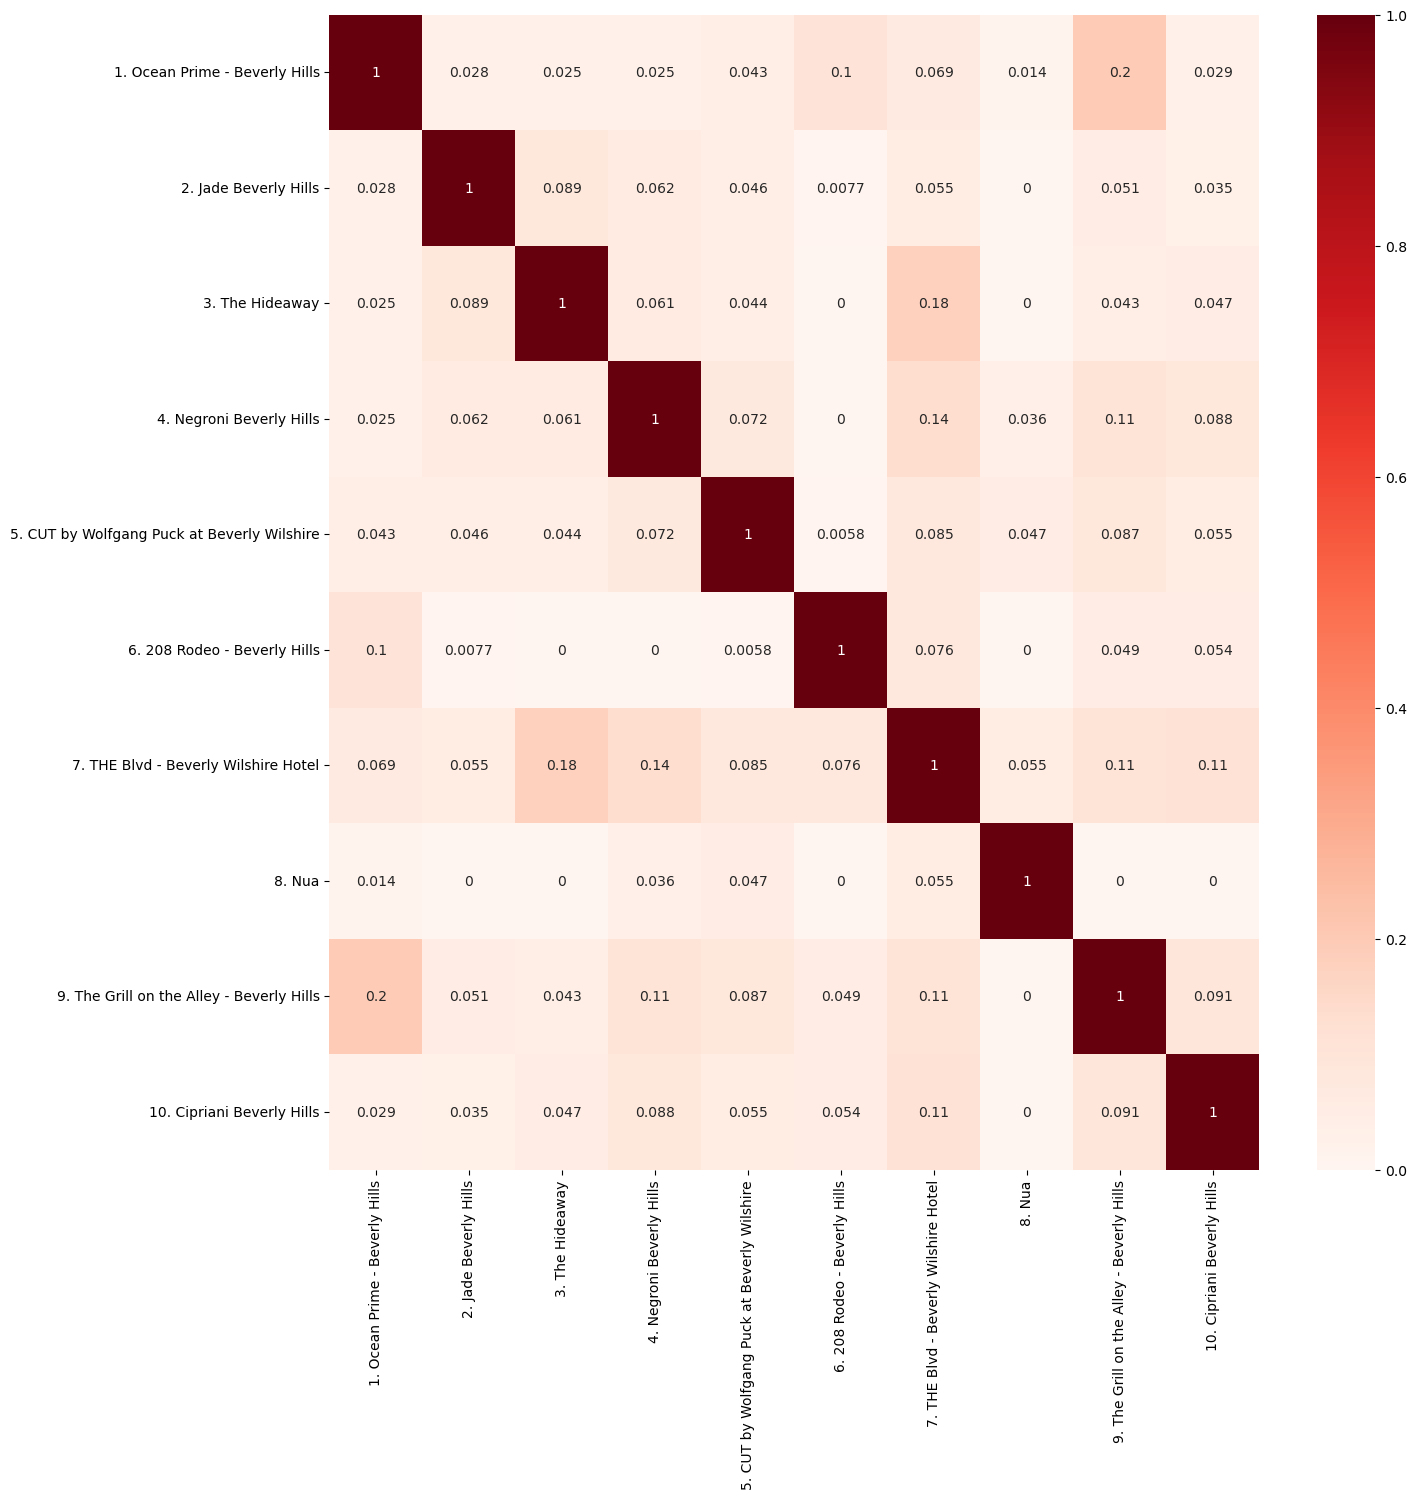

In [276]:
plt.figure(figsize =(15,15))
sns.heatmap(cos_sim, cmap="Reds", annot = True, yticklabels = names0, xticklabels = names0)
plt.show()

# My findings from the heatmap.

### 1. Nua seems to be the most outstanding among the list of 10 aforementioned restaurants because it has the low similarity with most others (e.g. Cipriani, 208 Rodeo, the Grill, Jade,..)

### 2. The Blvd and the Hideaway has the highest cosine similarity among 10 aforementioned restaurant. In details, both of them seems to have the vibrant outdoor spaces, beautiful bar area and a top spot for cocktails Therefore, it is recommended that we should not open the same type of restaurants but consider the niches like Nua restaurant